<a href="https://colab.research.google.com/github/freyebeans/ASU-assignments/blob/main/MAT422/HW1.3/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MAT422 Section 1.3 Linear Regression
Michael Bishop

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

## 1.3.1 QR Decomposition
Provided a matrix *A* we can find a matrix with orthonormal columns *Q* and a upper triangular matrix *R* such that *A*=*QR*. The proccess of finding these matrices is called QR decomposition.

In [ ]:
A = np.array([[1,0],[1,2],[1,4],[1,6],[1,8]])

Q, R = np.linalg.qr(A)

print("A =")
print(A)
print("Q =")
print(Q)
print("R =")
print(R)
print("Q.T * Q")
print(Q.T @ Q)
print("does Q have orthonormal columns?",np.allclose(Q.T @ Q, np.eye(Q.shape[1])))
print("Q * R")
QR = Q @ R
print(QR)
print("does QR = A?",np.allclose(QR, A))

A =
[[1 0]
 [1 2]
 [1 4]
 [1 6]
 [1 8]]
Q =
[[-0.4472 -0.6325]
 [-0.4472 -0.3162]
 [-0.4472  0.    ]
 [-0.4472  0.3162]
 [-0.4472  0.6325]]
R =
[[-2.2361 -8.9443]
 [ 0.      6.3246]]
Q.T * Q
[[ 1. -0.]
 [-0.  1.]]
does Q have orthonormal columns? True
Q * R
[[ 1. -0.]
 [ 1.  2.]
 [ 1.  4.]
 [ 1.  6.]
 [ 1.  8.]]
does QR = A? True


As you can see *A*=*QR* is true and matrix *Q* has orthonormal columns.<br>
It is useful to find this matrix *Q* with orthonormal columns as projections and certain least-squares calculations are cleaner with these kinds of matrices.
## 1.3.2 Least-Squares Problems
A least-squares problem involves finding the best solution to an overdetermined system, *A***x** ~ **b**. Overdetermined systems often have no exact solution, so least-squares probelms typically revolve around minimizing the residual norm ||**b** - *A***x**|| and finding the best possible solution.

In [ ]:
b = np.array([-0.1,1.1,1.8,3.2,4.1])

x_lstsq, residual_sum, rank, values = np.linalg.lstsq(A,b)
residual = b - A @ x_lstsq

print("least-squares solution from np.linalg.lstsq(A,b)", x_lstsq)
print("residual (b - Ax) =", residual)
print("norm of residual =", np.linalg.norm(residual))
print("rank of A =",np.linalg.matrix_rank(A))
print("sigular values =", values)
print("normal-equation check A.T * residual =",A.T @ residual)

least-squares solution from np.linalg.lstsq(A,b) [-0.08   0.525]
residual (b - Ax) = [-0.02  0.13 -0.22  0.13 -0.02]
norm of residual = 0.28809720581775894
rank of A = 2
sigular values = [11.1076  1.2732]
normal-equation check A.T * residual = [ 0. -0.]


With QR decomposition.

In [ ]:
QTb = Q.T @ b
x_qr = np.linalg.solve(R,QTb)
qr_residual = b - A @ x_qr

print("Q.T * b =",QTb)
print("least-squares solution from QR decomposition", x_qr)
print("norm of residual =", np.linalg.norm(qr_residual))

print("\ndoes the QR decomposition solution match the np.linalg.lstsq() solution?",np.allclose(x_qr, x_lstsq))

Q.T * b = [-4.5169  3.3204]
least-squares solution from QR decomposition [-0.08   0.525]
norm of residual = 0.28809720581775866

does the QR decomposition solution match the np.linalg.lstsq() solution? True


As you can see the normal-equation $A^T\textbf{r}$ for residual **r** is close to zero, meaning that **r** is orthogonal to the columns space of *A*. Additionally you can see that `np.linalg.lstsq(A,b)` yields the same results as using QR decomposition.
## 1.3.3 Linear Regression
Simple linear regression is an example of a least-squares problem. Take a line defined by the equation $y = \beta _0+\beta _1x$, the design matrix for the line *X* is $\begin{bmatrix}1 & x_0\\\vdots & \vdots\\1 & x_n\end{bmatrix}$ where the ones correspond to the intercept and $x_i$ is the i-th element in a set of $n$ x values. Solving the least-squares problem yields a slope and intercept for a line that most closely fits the data in $x$ and $y$.

In [ ]:
x = np.array([0,1,2,3,4,5,6])
y = np.array([1.9,3.6,5.1,6.3,8.2,9.4,11])

X = np.column_stack([np.ones_like(x),x])
beta, *_ = np.linalg.lstsq(X, y)
predicted_y = X @ beta
residuals = y - predicted_y
rmse = np.sqrt(np.mean(residuals**2))

print("design matrix X =")
print(X)
print("intercept (beta_0) =", beta[0])
print("slope (beta_1) =", beta[1])
print("predicted y =", predicted_y)
print("residuals =", residuals)
print("RMSE (root mean square error) =", rmse)

design matrix X =
[[1 0]
 [1 1]
 [1 2]
 [1 3]
 [1 4]
 [1 5]
 [1 6]]
intercept (beta_0) = 1.9999999999999987
slope (beta_1) = 1.5000000000000007
predicted y = [ 2.   3.5  5.   6.5  8.   9.5 11. ]
residuals = [-0.1  0.1  0.1 -0.2  0.2 -0.1 -0. ]
RMSE (root mean square error) = 0.13093073414159503


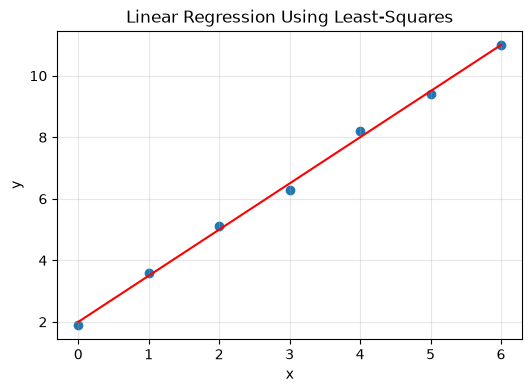

In [ ]:
plt.figure(figsize=(6,4))
plt.grid(True, alpha = 0.3)
plt.scatter(x,y,color="tab:blue")
plt.plot(x, predicted_y, "r")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Linear Regression Using Least-Squares")
plt.show()

The slope $\beta _1$ indicates that for every unit increase in x, the value of y typically increases by roughly 1.5. The intercept $\beta _0$ indicates that when x = 0, y is roughly equal to 2. The RMSE indicates that the data points are typically off by around 0.131 from the line of best fit.
## Reflection and Rubric Checklist
- I ran the notebook in its entirety without error.
- I covered QR decomposition, least-squares, and linear regression.
- The examples clearly demonstrate the concepts.
- I explained each concpet before and after the code.
- I organized the notebook in a logical way with headers and readable code.
- I changed and extended at least one example so that the notebook reflects my own work.
- I saved the notebook from Google Colab directly to GitHub as per course instructions.